# 01 — Task 1: LOS / NLOS Classification

Runs all six classifiers on prepared features loaded from `data/prepared/`. Run `00_Data_Prep.ipynb` first.

## Imports

In [1]:
from pathlib import Path; Path("results/classification").mkdir(parents=True, exist_ok=True)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
from pathlib import Path
import joblib, json

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score
)

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
    print("XGBoost:", xgb.__version__)
except Exception:
    XGB_AVAILABLE = False
    print("XGBoost not available.")

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    TF_AVAILABLE = True
    print("TensorFlow:", tf.__version__)
except Exception:
    TF_AVAILABLE = False
    print("TensorFlow not available — CNN section will be skipped.")

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 40)
print("Imports loaded.")

XGBoost: 3.2.0
TensorFlow: 2.21.0
Imports loaded.


## Load Prepared Data

In [2]:
# Load prepared data from 00_Data_Prep.ipynb ────────────────────────────────
d1 = np.load("data/prepared/task1_data.npz")
X_train_sel = d1["X_train_sel"]
X_test_sel  = d1["X_test_sel"]
X_tr_sel_sc = d1["X_tr_sel_sc"]
X_te_sel_sc = d1["X_te_sel_sc"]
y_train     = d1["y_train"]
y_test      = d1["y_test"]
y_class     = d1["y_class"]

cir_matrix  = np.load("data/prepared/cir_matrix.npy")
scaler_sel  = joblib.load("data/prepared/scaler_clf.pkl")

with open("data/prepared/metadata.json") as f:
    meta = json.load(f)
RANDOM_STATE          = meta["RANDOM_STATE"]
selected_clf_features = meta["selected_clf_features"]
FEATURE_NAMES         = meta["FEATURE_NAMES"]

print(f"Task 1 data loaded:")
print(f"  Train : {X_train_sel.shape[0]:,} samples, {X_train_sel.shape[1]} features")
print(f"  Test  : {X_test_sel.shape[0]:,} samples")
print(f"  CIR   : {cir_matrix.shape}")
print(f"  Selected features: {selected_clf_features}")

Task 1 data loaded:
  Train : 33,600 samples, 15 features
  Test  : 8,400 samples
  CIR   : (42000, 1017)
  Selected features: ['cir_max', 'cir_std', 'cir_energy', 'RANGE', 'RXPACC', 'cir_rms', 'cir_mean', 'FP_AMP3', 'CIR_PWR', 'FP_AMP2', 'MAX_NOISE', 'cir_skewness', 'FP_AMP1', 'cir_kurtosis', 'STDEV_NOISE']


In [3]:
# Dictionaries to collect results across models
clf_results  = {}   # classification: {model_name: {accuracy, f1, auc, ...}}
reg_results  = {}   # regression:     {model_name: {rmse, mae, r2}}
roc_data     = {}   # {model_name: (fpr, tpr, auc)} for ROC overlay plot
trained_clfs = {}   # store trained classifiers for confusion matrix plots

def evaluate_classifier(name, model, X_tr, y_tr, X_te, y_te, proba=True):
    """Fit, predict, and store classification metrics."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    if proba and hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_te)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_te)
    else:
        y_score = None

    from sklearn.metrics import f1_score, precision_score, recall_score
    acc  = accuracy_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec  = recall_score(y_te, y_pred)
    auc  = roc_auc_score(y_te, y_score) if y_score is not None else float('nan')

    clf_results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'AUC-ROC': auc}
    trained_clfs[name] = (model, y_pred)

    if y_score is not None:
        fpr, tpr, _ = roc_curve(y_te, y_score)
        roc_data[name] = (fpr, tpr, auc)

    print(f"  {name:<22} Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}")
    return model

def evaluate_regressor(name, model, X_tr, y_tr, X_te, y_te):
    """Fit, predict, and store regression metrics."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae  = mean_absolute_error(y_te, y_pred)
    r2   = r2_score(y_te, y_pred)
    reg_results[name] = {'RMSE': rmse, 'MAE': mae, 'R²': r2}
    print(f"  {name:<22} RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}")
    return model, y_pred


---
## Data Mining Strategy

---

We chose **supervised learning** for both tasks. The dataset provides 42,000 labelled samples with a known ground truth `NLOS` column, so unsupervised clustering would discard useful information. Clustering also gives no guarantee that the resulting groups align with LOS/NLOS — they could just as easily reflect differences in environment type or measurement distance.

**Task 1 — Binary classification:** Predict `NLOS` ∈ {0, 1} from CIR signal features. We compare six classifiers across different model families to find what works best for this data.

**Task 2 / 2b — Regression:** Predict measured range in metres. This requires a continuous output, so regression is the only appropriate choice.

| Algorithm | Task | Why included |
|---|---|---|
| Logistic Regression | Classification | Linear baseline; interpretable weights |
| Random Forest | Both | Robust ensemble; gives feature importance natively |
| XGBoost | Both | Strong tabular performance; handles mixed-quality features well |
| LinearSVC | Classification | Efficient maximum-margin classifier |
| MLP | Both | Captures nonlinear interactions between CIR features |
| 1D CNN | Classification | Learns directly from raw CIR waveform without manual feature engineering |

---
# TASK 1 — LOS / NLOS Classification

---

## 6. Logistic Regression (Baseline)

Logistic Regression predicts class probabilities by applying a sigmoid to a weighted sum of the input features:

$$P(y=1 \mid \mathbf{x}) = \frac{1}{1 + e^{-(\mathbf{w}^\top \mathbf{x} + b)}}$$

Training minimises cross-entropy loss with L2 regularisation:

$$\mathcal{L} = -\sum_{i} \left[ y_i \log \hat{p}_i + (1-y_i) \log(1-\hat{p}_i) \right] + \frac{\lambda}{2} \|\mathbf{w}\|^2$$

We include it as a **baseline** to establish a performance floor. The EDA showed strong linear correlations between features like RXPACC and NLOS status, so it should perform reasonably well already. If the nonlinear models don't clearly outperform it, that would suggest the LOS/NLOS boundary is mostly linear and a simple model would suffice in practice.

The limitation is the linear decision boundary — UWB channel conditions involve nonlinear interactions between features (e.g., how amplitude and noise jointly indicate NLOS), which logistic regression cannot capture. We expect the ensemble and neural network models to pull ahead on this.

In [4]:
print("=" * 60)
print("LOGISTIC REGRESSION")
print("=" * 60)

lr_clf = LogisticRegression(
    C=1.0,
    max_iter=1000,
    solver='lbfgs',
    random_state=RANDOM_STATE
)

evaluate_classifier('Logistic Regression', lr_clf, X_tr_sel_sc, y_train, X_te_sel_sc, y_test)

print("\nDetailed classification report:")
print(classification_report(y_test, lr_clf.predict(X_te_sel_sc), target_names=['LOS', 'NLOS']))

LOGISTIC REGRESSION
  Logistic Regression    Acc=0.8595  F1=0.8550  AUC=0.9242

Detailed classification report:
              precision    recall  f1-score   support

         LOS       0.84      0.89      0.86      4200
        NLOS       0.88      0.83      0.86      4200

    accuracy                           0.86      8400
   macro avg       0.86      0.86      0.86      8400
weighted avg       0.86      0.86      0.86      8400



## 7. Random Forest

### Theory

Random Forest is an **ensemble of decision trees** trained using bagging (Bootstrap Aggregating) and random feature subspace selection:

1. For each tree $t = 1, \ldots, T$: draw a bootstrap sample $\mathcal{D}_t$ from the training data
2. At each node split, consider only a random subset of $m = \lfloor\sqrt{p}\rfloor$ features (where $p$ is the total number of features)
3. Select the feature and threshold that maximises the **Gini impurity** reduction:
   $$\Delta G = G_{\text{parent}} - \frac{n_L}{n} G_L - \frac{n_R}{n} G_R$$
   where $G = 1 - \sum_k p_k^2$
4. Final prediction: majority vote across all $T$ trees

$$\hat{y} = \text{mode}\{h_1(\mathbf{x}), h_2(\mathbf{x}), \ldots, h_T(\mathbf{x})\}$$

### Why Random Forest for UWB LOS/NLOS?

- **Non-linear decision boundaries**: UWB signal classification involves nonlinear interactions between amplitude, noise, and CIR shape features. Random Forest captures these through deep tree splits.
- **Feature importance**: The MDI importance scores directly support the project brief requirement for feature ranking.
- **Robustness**: Bagging reduces variance. With 7 different indoor environments contributing to the dataset, some environment-specific noise is expected. Averaging over many trees reduces the risk of overfitting to any one environment.
- **No scaling required**: Random Forest is invariant to feature scale — the relative ordering of values within each feature is all that matters for splits.
- **Established in literature**: Random Forest is widely used in UWB NLOS identification. Stahlke et al. (2020) achieved >97% classification accuracy using RF on similar UWB CIR features.

### Hyperparameters

| Parameter | Value | Reasoning |
|---|---|---|
| `n_estimators=200` | 200 trees | Diminishing returns beyond ~200; more trees = lower variance |
| `max_depth=None` | Unlimited | Allow trees to fully learn; bagging controls overfitting |
| `min_samples_leaf=2` | 2 | Prevent single-sample leaves (reduces overfitting) |
| `n_jobs=-1` | All cores | Parallel training for speed |

In [5]:
print("=" * 60)
print("RANDOM FOREST CLASSIFIER")
print("=" * 60)

rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

evaluate_classifier('Random Forest', rf_clf, X_train_sel, y_train, X_test_sel, y_test)

print("\nDetailed classification report:")
print(classification_report(y_test, rf_clf.predict(X_test_sel), target_names=['LOS', 'NLOS']))

RANDOM FOREST CLASSIFIER
  Random Forest          Acc=0.9165  F1=0.9155  AUC=0.9739

Detailed classification report:
              precision    recall  f1-score   support

         LOS       0.91      0.93      0.92      4200
        NLOS       0.93      0.90      0.92      4200

    accuracy                           0.92      8400
   macro avg       0.92      0.92      0.92      8400
weighted avg       0.92      0.92      0.92      8400



## 8. XGBoost (Gradient Boosting)

### Theory

XGBoost (eXtreme Gradient Boosting, Chen & Guestrin, 2016) is a **sequential ensemble** method that builds trees additively, where each new tree corrects the residual errors of the previous ensemble. The model prediction after $M$ iterations is:

$$\hat{y}^{(M)} = \sum_{m=1}^{M} \eta \cdot h_m(\mathbf{x})$$

where $\eta$ is the learning rate and $h_m$ is the $m$-th tree trained to minimise the **second-order Taylor approximation** of the loss:

$$\mathcal{L}^{(m)} \approx \sum_i \left[ g_i f_m(\mathbf{x}_i) + \frac{1}{2} h_i f_m(\mathbf{x}_i)^2 \right] + \Omega(f_m)$$

where $g_i = \partial_{\hat{y}^{(m-1)}} \ell(y_i, \hat{y}^{(m-1)})$ and $h_i = \partial^2_{\hat{y}^{(m-1)}} \ell(y_i, \hat{y}^{(m-1)})$ are the first and second-order gradients, and $\Omega(f) = \gamma T + \frac{1}{2}\lambda\|w\|^2$ is a regularisation term on tree complexity.

For binary classification, XGBoost uses **log-loss** as the objective, producing output probabilities via the sigmoid function.

### Why XGBoost for UWB LOS/NLOS?

- **State-of-the-art tabular performance**: XGBoost consistently outperforms other algorithms on structured/tabular data. The metadata + CIR statistical features constitute a tabular problem well-suited to gradient boosting.
- **Handles feature interactions**: Boosting builds trees that focus on misclassified examples, naturally learning hard boundary cases where LOS and NLOS signals overlap (as seen in the PCA plot from EDA).
- **Built-in regularisation**: The $\Omega$ term penalises tree complexity, reducing overfitting without sacrificing accuracy.
- **Speed**: XGBoost uses histogram-based split finding and parallelism, making it fast even at 33,000 training samples.
- **Key difference from Random Forest**: RF builds trees independently (parallel); XGBoost builds trees sequentially (serial), where each tree specifically targets the remaining errors — this generally achieves higher accuracy at the cost of tuning sensitivity.

In [6]:
print("=" * 60)
print("XGBOOST CLASSIFIER")
print("=" * 60)

if XGB_AVAILABLE:
    xgb_clf = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    evaluate_classifier('XGBoost', xgb_clf, X_train_sel, y_train, X_test_sel, y_test)
    print("\nDetailed classification report:")
    print(classification_report(y_test, xgb_clf.predict(X_test_sel), target_names=['LOS', 'NLOS']))
else:
    print("Skipped — XGBoost not installed.")

XGBOOST CLASSIFIER
  XGBoost                Acc=0.9207  F1=0.9193  AUC=0.9773

Detailed classification report:
              precision    recall  f1-score   support

         LOS       0.91      0.94      0.92      4200
        NLOS       0.94      0.90      0.92      4200

    accuracy                           0.92      8400
   macro avg       0.92      0.92      0.92      8400
weighted avg       0.92      0.92      0.92      8400



## 9. Linear Support Vector Machine (LinearSVC)

### Theory

A Support Vector Machine finds the **maximum-margin hyperplane** separating the two classes. The decision function is:

$$f(\mathbf{x}) = \mathbf{w}^\top \mathbf{x} + b$$

$$\hat{y} = \text{sign}(f(\mathbf{x}))$$

The primal optimisation problem (with soft margin for non-separable data) is:

$$\min_{\mathbf{w}, b, \boldsymbol{\xi}} \frac{1}{2}\|\mathbf{w}\|^2 + C \sum_{i=1}^{n} \xi_i$$

subject to: $y_i(\mathbf{w}^\top \mathbf{x}_i + b) \geq 1 - \xi_i$ and $\xi_i \geq 0$

The parameter $C$ controls the **bias-variance trade-off**: large $C$ penalises misclassifications heavily (low bias, high variance); small $C$ allows more margin violations (high bias, low variance).

**LinearSVC** solves this using the dual form via coordinate descent, making it $O(n \cdot p)$ — practical for the 33,600 × 19 training matrix.

### Why SVM for UWB LOS/NLOS?

- **Effective in high-dimensional spaces**: SVMs were originally designed for high-dimensional feature spaces and remain competitive even with 19 features.
- **Maximum margin principle**: The EDA PCA plot showed classes with some overlap. SVM maximises the margin between classes, making it robust to noisy boundary samples.
- **Literature precedent**: SVMs have been used for UWB NLOS detection in several published studies. Güvenç & Chong (2009) demonstrated SVM-based LOS/NLOS identification using similar signal statistics features.
- **Limitation — linear only**: A linear SVM cannot capture nonlinear class boundaries. The kernel SVM (RBF) would handle this but is $O(n^2)$ in training time, making it impractical for 33,600 samples. LinearSVC provides the linear baseline while remaining computationally tractable.

In [7]:
print("=" * 60)
print("LINEAR SVM (LinearSVC)")
print("=" * 60)

svm_clf = LinearSVC(
    C=1.0,
    max_iter=5000,
    random_state=RANDOM_STATE
)

# LinearSVC has no predict_proba; use decision_function for ROC
evaluate_classifier('Linear SVM', svm_clf, X_tr_sel_sc, y_train, X_te_sel_sc, y_test, proba=False)

print("\nDetailed classification report:")
print(classification_report(y_test, svm_clf.predict(X_te_sel_sc), target_names=['LOS', 'NLOS']))

LINEAR SVM (LinearSVC)
  Linear SVM             Acc=0.8583  F1=0.8528  AUC=0.9241

Detailed classification report:
              precision    recall  f1-score   support

         LOS       0.83      0.90      0.86      4200
        NLOS       0.89      0.82      0.85      4200

    accuracy                           0.86      8400
   macro avg       0.86      0.86      0.86      8400
weighted avg       0.86      0.86      0.86      8400



## 10. Multilayer Perceptron (MLP)

### Theory

A Multilayer Perceptron is a **fully-connected feedforward neural network** with one or more hidden layers. Each layer computes:

$$\mathbf{h}^{(l)} = \phi\left(\mathbf{W}^{(l)} \mathbf{h}^{(l-1)} + \mathbf{b}^{(l)}\right)$$

where $\phi$ is an activation function. The **ReLU** activation is used for hidden layers:

$$\text{ReLU}(x) = \max(0, x)$$

ReLU is preferred over sigmoid/tanh because it does not saturate for large positive values, enabling faster gradient flow during backpropagation (mitigating the vanishing gradient problem).

The output layer uses the **sigmoid** function for binary classification:

$$P(y=1 \mid \mathbf{x}) = \sigma(\mathbf{w}^{(L)\top} \mathbf{h}^{(L-1)} + b^{(L)})$$

Training minimises **binary cross-entropy** via **backpropagation** and **Adam optimiser** (adaptive moment estimation).

### Architecture Design

Network: **19 → 256 → 128 → 64 → 1**

- The three hidden layers provide sufficient depth to learn the nonlinear decision surface
- Layer widths decrease pyramidally (256 → 128 → 64), compressing the representation toward the classification boundary
- Early stopping monitors validation loss to prevent overfitting

### Why MLP for UWB LOS/NLOS?

- **Direct academic reference**: The project brief references paper [2]: *"NLOS Channel Detection with Multilayer Perceptron in Low-Rate Personal Area Networks"* — the professor is explicitly pointing to MLP as a relevant architecture for this exact problem.
- **Universal approximation**: By the Universal Approximation Theorem (Cybenko, 1989), an MLP with sufficient width can approximate any continuous function on a compact domain — meaning it can in principle learn any decision boundary separating LOS from NLOS signals.
- **Nonlinear interactions**: MLP learns multiplicative interactions between features through its weight matrices, capturing complex multi-feature signal patterns that linear models miss.

In [8]:
print("=" * 60)
print("MULTILAYER PERCEPTRON (MLP)")
print("=" * 60)

mlp_clf = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=RANDOM_STATE
)

evaluate_classifier('MLP', mlp_clf, X_tr_sel_sc, y_train, X_te_sel_sc, y_test)

print("\nDetailed classification report:")
print(classification_report(y_test, mlp_clf.predict(X_te_sel_sc), target_names=['LOS', 'NLOS']))

MULTILAYER PERCEPTRON (MLP)
  MLP                    Acc=0.9208  F1=0.9198  AUC=0.9776

Detailed classification report:
              precision    recall  f1-score   support

         LOS       0.91      0.93      0.92      4200
        NLOS       0.93      0.91      0.92      4200

    accuracy                           0.92      8400
   macro avg       0.92      0.92      0.92      8400
weighted avg       0.92      0.92      0.92      8400



## 11. 1D Convolutional Neural Network (1D CNN)

### Theory

A 1D Convolutional Neural Network applies **learnable filters** (kernels) across the time dimension of the input signal. For a 1D input $\mathbf{x} \in \mathbb{R}^T$ and a filter $\mathbf{k} \in \mathbb{R}^K$, the convolution output at position $t$ is:

$$y[t] = \sum_{k=0}^{K-1} \mathbf{x}[t+k] \cdot \mathbf{k}[k] + b$$

The key properties that make 1D CNNs ideal for signal data:

- **Translational invariance**: A feature detector (e.g., a sharp rising edge) is detected regardless of its position in the waveform — critical because the LOS first-path peak occurs at different time indices across samples (FP_IDX varies from 707 to 848)
- **Parameter sharing**: The same filter weights are applied at every position, drastically reducing parameters compared to a fully-connected layer
- **Hierarchical feature learning**: Early layers detect local patterns (e.g., sharp peaks); deeper layers combine local patterns into global signal characteristics (e.g., multi-path structure)

**MaxPooling** reduces the spatial dimension by selecting the maximum activation in each pooling window, providing down-sampling and further translational robustness.

### Architecture

```
Input: (1016, 1)          — raw CIR waveform, per-sample normalised
  → Conv1D(32, kernel=5, ReLU)   — 32 local pattern detectors, 5ns window
  → MaxPooling1D(2)               — downsample by 2
  → Conv1D(64, kernel=5, ReLU)   — 64 higher-order patterns
  → MaxPooling1D(2)
  → Conv1D(128, kernel=3, ReLU)  — 128 abstract features
  → GlobalAveragePooling1D()      — aggregate across entire remaining sequence
  → Dense(64, ReLU)
  → Dropout(0.3)                  — regularisation
  → Dense(1, Sigmoid)             — binary output
```

### Why 1D CNN for UWB LOS/NLOS?

- **Raw waveform input**: Unlike the other models that use hand-crafted statistical features, the CNN learns directly from the 1,016-sample CIR waveform. This is **end-to-end learning** — no feature engineering needed.
- **EDA evidence**: The CIR visualisations from EDA showed that LOS signals have a concentrated, sharp early-arriving peak while NLOS signals have dispersed, multi-path energy. A Conv1D filter with a 5ns window is perfectly sized to detect such localised peaks.
- **State-of-the-art**: CNNs applied to raw CIR waveforms represent the current state-of-the-art in UWB LOS/NLOS identification. Bregar & Mohorcic (2018) achieved >98% accuracy using a CNN on the DW1000 CIR, outperforming all statistical feature-based approaches.
- **Per-sample normalisation**: Each CIR is divided by its own maximum value before input. This removes absolute amplitude effects, forcing the network to focus on *shape* rather than *magnitude* — important because signal strength varies with distance and is not a reliable LOS/NLOS indicator on its own.

In [9]:
print("=" * 60)
print("1D CONVOLUTIONAL NEURAL NETWORK")
print("=" * 60)

if TF_AVAILABLE:
    # cir_matrix is already RXPACC-normalised in the preprocessing step
    X_cir_tr, X_cir_te, y_cir_tr, y_cir_te = train_test_split(
        cir_matrix, y_class, test_size=0.2, random_state=RANDOM_STATE, stratify=y_class
    )

    # Reshape to (n_samples, timesteps, channels) for Conv1D
    X_cir_tr = X_cir_tr[:, :, np.newaxis]  # (33600, 1016, 1)
    X_cir_te = X_cir_te[:, :, np.newaxis]  # (8400,  1016, 1)

    n_timesteps = X_cir_tr.shape[1]

     # Build model
    tf.random.set_seed(RANDOM_STATE)
    cnn_model = keras.Sequential([
        layers.Input(shape=(n_timesteps, 1)),
        layers.Conv1D(filters=32, kernel_size=5, activation='relu', padding='same'),
        layers.MaxPooling1D(pool_size=2),
        layers.Conv1D(filters=64, kernel_size=5, activation='relu', padding='same'),
        layers.MaxPooling1D(pool_size=2),
        layers.Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ], name='CNN_1D')

    cnn_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    cnn_model.summary()
else:
    print("TensorFlow not available — skipping 1D CNN.")

1D CONVOLUTIONAL NEURAL NETWORK


Model: "CNN_1D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 1017, 32)            │             192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 508, 32)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 508, 64)             │          10,304 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 254, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 254, 128)            │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 43,521 (170.00 KB)

 Trainable params: 43,521 (170.00 KB)

 Non-trainable params: 0 (0.00 B)

Training 1D CNN (epochs=50, patience=10)...
Epoch 1/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - accuracy: 0.7798 - loss: 0.4444 - val_accuracy: 0.8607 - val_loss: 0.3447
Epoch 2/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.8580 - loss: 0.3463 - val_accuracy: 0.8616 - val_loss: 0.3290
Epoch 3/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.8601 - loss: 0.3369 - val_accuracy: 0.8613 - val_loss: 0.3227
Epoch 4/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.8615 - loss: 0.3340 - val_accuracy: 0.8613 - val_loss: 0.3190
Epoch 5/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.8637 - loss: 0.3283 - val_accuracy: 0.8667 - val_loss: 0.3146
Epoch 6/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.8647 - loss: 0.3244 - val_accuracy: 0.8676 - val_loss: 0.3103
Epoch 7/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.8672 - loss: 0.3205 - val_accuracy: 0.8714 - val_loss: 0.3054
Epoch 8/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/s

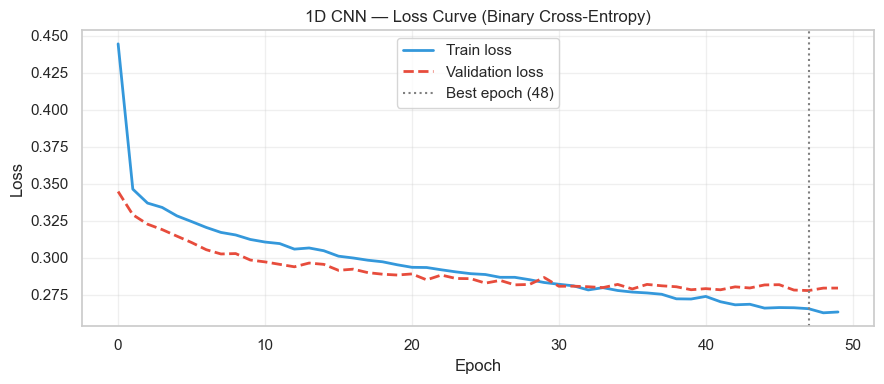

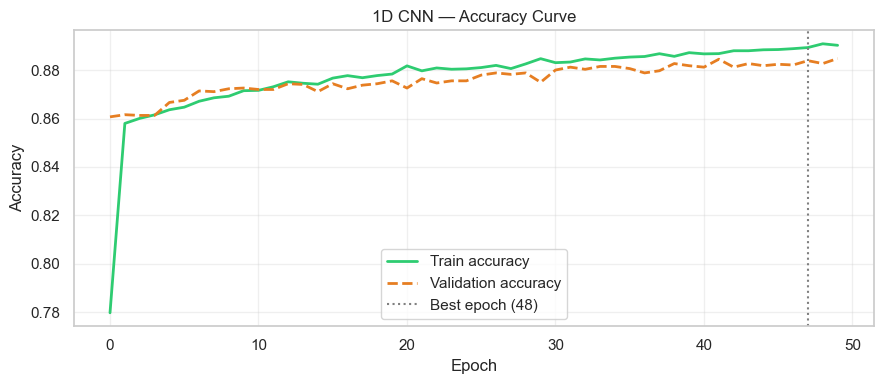

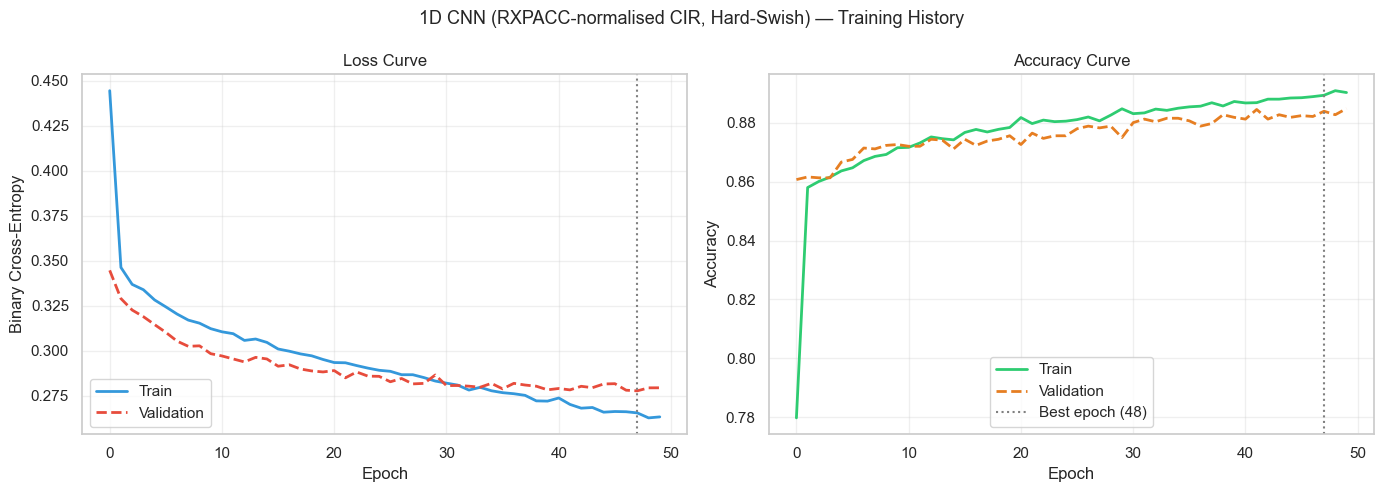

Figures saved to results/classification/


In [10]:
if TF_AVAILABLE:
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )

    print("Training 1D CNN (epochs=50, patience=10)...")
    cnn_history = cnn_model.fit(
        X_cir_tr, y_cir_tr,
        epochs=50,
        batch_size=128,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=1
    )

    # Print final epoch metrics ─────────────────────────────────────────────
    epochs_run = len(cnn_history.history['loss'])
    best_epoch = int(np.argmin(cnn_history.history['val_loss'])) + 1
    print(f"\nTraining completed: {epochs_run} epochs run, best weights from epoch {best_epoch}")
    print(f"  Final train loss     : {cnn_history.history['loss'][-1]:.4f}")
    print(f"  Final val loss       : {cnn_history.history['val_loss'][-1]:.4f}")
    print(f"  Final train accuracy : {cnn_history.history['accuracy'][-1]:.4f}")
    print(f"  Final val accuracy   : {cnn_history.history['val_accuracy'][-1]:.4f}")
    print(f"  Best val loss        : {min(cnn_history.history['val_loss']):.4f}  (epoch {best_epoch})")
    print(f"  Best val accuracy    : {max(cnn_history.history['val_accuracy']):.4f}")

    # Loss curve ────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(cnn_history.history['loss'],     label='Train loss',      color='#3498db', linewidth=2)
    ax.plot(cnn_history.history['val_loss'], label='Validation loss', color='#e74c3c', linewidth=2, linestyle='--')
    ax.axvline(best_epoch - 1, color='gray', linestyle=':', linewidth=1.5, label=f'Best epoch ({best_epoch})')
    ax.set_title('1D CNN — Loss Curve (Binary Cross-Entropy)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('results/classification/cnn_loss_curve.png', dpi=120, bbox_inches='tight')
    plt.show()

    # Accuracy curve ────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(cnn_history.history['accuracy'],     label='Train accuracy',      color='#2ecc71', linewidth=2)
    ax.plot(cnn_history.history['val_accuracy'], label='Validation accuracy', color='#e67e22', linewidth=2, linestyle='--')
    ax.axvline(best_epoch - 1, color='gray', linestyle=':', linewidth=1.5, label=f'Best epoch ({best_epoch})')
    ax.set_title('1D CNN — Accuracy Curve')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('results/classification/cnn_accuracy_curve.png', dpi=120, bbox_inches='tight')
    plt.show()

    # Combined 2-panel summary ──────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(cnn_history.history['loss'],     label='Train',      color='#3498db', linewidth=2)
    axes[0].plot(cnn_history.history['val_loss'], label='Validation', color='#e74c3c', linewidth=2, linestyle='--')
    axes[0].axvline(best_epoch - 1, color='gray', linestyle=':', linewidth=1.5)
    axes[0].set_title('Loss Curve')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Binary Cross-Entropy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(cnn_history.history['accuracy'],     label='Train',      color='#2ecc71', linewidth=2)
    axes[1].plot(cnn_history.history['val_accuracy'], label='Validation', color='#e67e22', linewidth=2, linestyle='--')
    axes[1].axvline(best_epoch - 1, color='gray', linestyle=':', linewidth=1.5, label=f'Best epoch ({best_epoch})')
    axes[1].set_title('Accuracy Curve')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    fig.suptitle('1D CNN (RXPACC-normalised CIR, Hard-Swish) — Training History', fontsize=13)
    plt.tight_layout()
    plt.savefig('results/classification/cnn_training_history.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("Figures saved to results/classification/")

In [11]:
if TF_AVAILABLE:
    y_cnn_prob = cnn_model.predict(X_cir_te, verbose=0).ravel()
    y_cnn_pred = (y_cnn_prob >= 0.5).astype(int)

    from sklearn.metrics import f1_score, precision_score, recall_score
    acc  = accuracy_score(y_cir_te, y_cnn_pred)
    f1   = f1_score(y_cir_te, y_cnn_pred)
    prec = precision_score(y_cir_te, y_cnn_pred)
    rec  = recall_score(y_cir_te, y_cnn_pred)
    auc  = roc_auc_score(y_cir_te, y_cnn_prob)

    clf_results['1D CNN'] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'AUC-ROC': auc}
    trained_clfs['1D CNN'] = (cnn_model, y_cnn_pred)
    fpr, tpr, _ = roc_curve(y_cir_te, y_cnn_prob)
    roc_data['1D CNN'] = (fpr, tpr, auc)

    print(f"  {'1D CNN':<22} Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}")
    print("\nDetailed classification report:")
    print(classification_report(y_cir_te, y_cnn_pred, target_names=['LOS', 'NLOS']))
else:
    print("Skipped — TensorFlow not available.")

  1D CNN                 Acc=0.8845  F1=0.8815  AUC=0.9501

Detailed classification report:
              precision    recall  f1-score   support

         LOS       0.87      0.91      0.89      4200
        NLOS       0.91      0.86      0.88      4200

    accuracy                           0.88      8400
   macro avg       0.89      0.88      0.88      8400
weighted avg       0.89      0.88      0.88      8400



## 12. Classification Model Comparison

### Evaluation Metrics Explanation

| Metric | Formula | What it measures |
|---|---|---|
| **Accuracy** | $\frac{TP+TN}{TP+TN+FP+FN}$ | Overall correct predictions |
| **Precision** | $\frac{TP}{TP+FP}$ | Of predicted NLOS, how many are truly NLOS |
| **Recall** | $\frac{TP}{TP+FN}$ | Of true NLOS, how many are detected |
| **F1-Score** | $2\cdot\frac{P \cdot R}{P+R}$ | Harmonic mean of precision and recall |
| **AUC-ROC** | Area under ROC curve | Discriminability across all thresholds (1.0 = perfect) |

**In context of the positioning system:** A false negative (NLOS predicted as LOS) is more damaging than a false positive — it would cause the system to use a biased range measurement for positioning, leading to localisation error. Therefore, **Recall** (sensitivity to true NLOS) and **F1** are the most operationally relevant metrics.

In [12]:
# Comparison table ──────────────────────────────────────────────────────────
results_df = pd.DataFrame(clf_results).T.round(4)
results_df = results_df.sort_values('AUC-ROC', ascending=False)
print("\nClassification Model Comparison (sorted by AUC-ROC):")
print(results_df.to_string())


Classification Model Comparison (sorted by AUC-ROC):
                     Accuracy  Precision  Recall      F1  AUC-ROC
MLP                    0.9208     0.9316  0.9083  0.9198   0.9776
XGBoost                0.9207     0.9363  0.9029  0.9193   0.9773
Random Forest          0.9165     0.9268  0.9045  0.9155   0.9739
1D CNN                 0.8845     0.9054  0.8588  0.8815   0.9501
Logistic Regression    0.8595     0.8834  0.8283  0.8550   0.9242
Linear SVM             0.8583     0.8873  0.8210  0.8528   0.9241


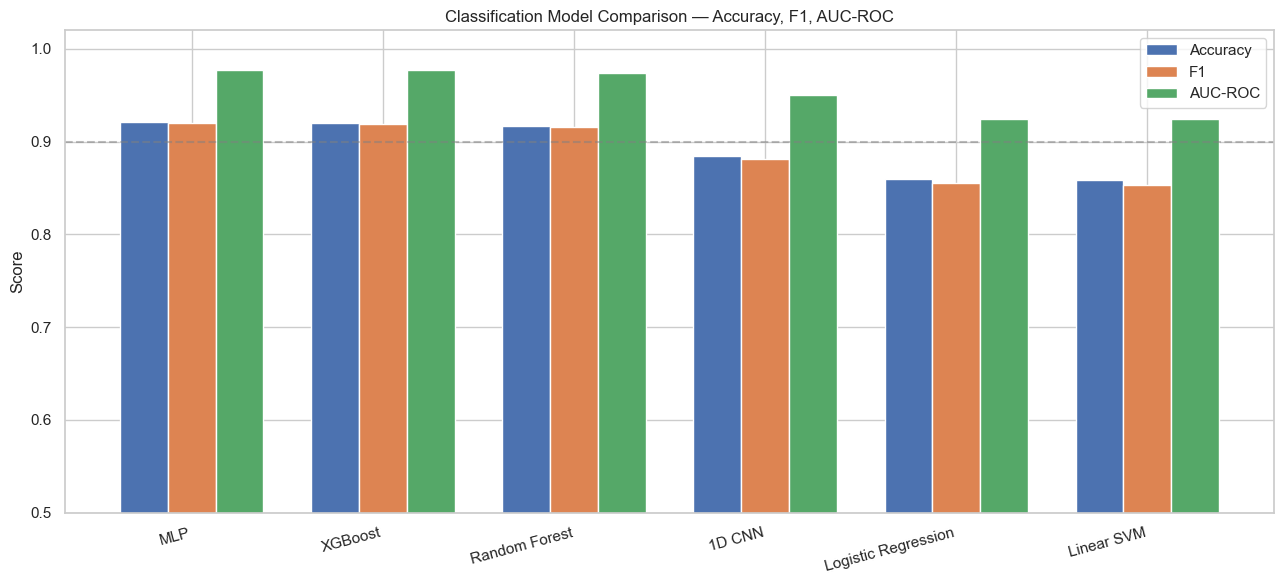

In [13]:
# Bar chart comparison ──────────────────────────────────────────────────────
metrics_to_plot = ['Accuracy', 'F1', 'AUC-ROC']
x = np.arange(len(results_df))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
for i, metric in enumerate(metrics_to_plot):
    bars = ax.bar(x + i * width, results_df[metric], width, label=metric)

ax.set_ylabel('Score')
ax.set_title('Classification Model Comparison — Accuracy, F1, AUC-ROC')
ax.set_xticks(x + width)
ax.set_xticklabels(results_df.index, rotation=15, ha='right')
ax.set_ylim(0.5, 1.02)
ax.legend()
ax.axhline(0.9, color='gray', linestyle='--', alpha=0.5, label='0.90 reference')
plt.tight_layout()
plt.savefig("results/classification/03_model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

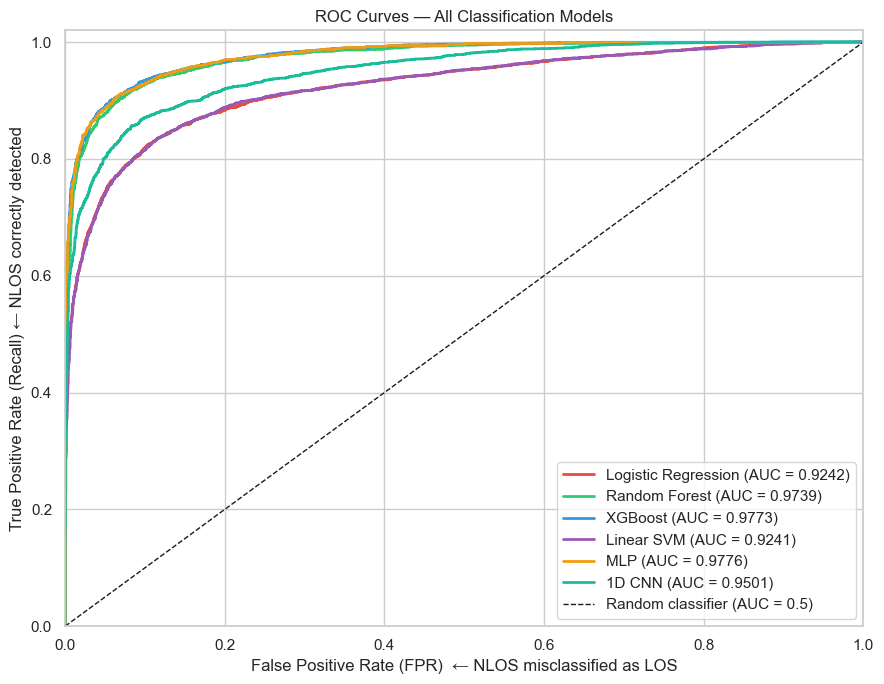

In [14]:
# ROC Curves ────────────────────────────────────────────────────────────────
plt.figure(figsize=(9, 7))

colors_roc = ['#e74c3c', '#2ecc71', '#3498db', '#9b59b6', '#f39c12', '#1abc9c']
for (name, (fpr, tpr, auc)), color in zip(roc_data.items(), colors_roc):
    plt.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.02])
plt.xlabel('False Positive Rate (FPR)  ← NLOS misclassified as LOS')
plt.ylabel('True Positive Rate (Recall) ← NLOS correctly detected')
plt.title('ROC Curves — All Classification Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("results/classification/04_roc_curves.png", dpi=120, bbox_inches="tight")
plt.show()

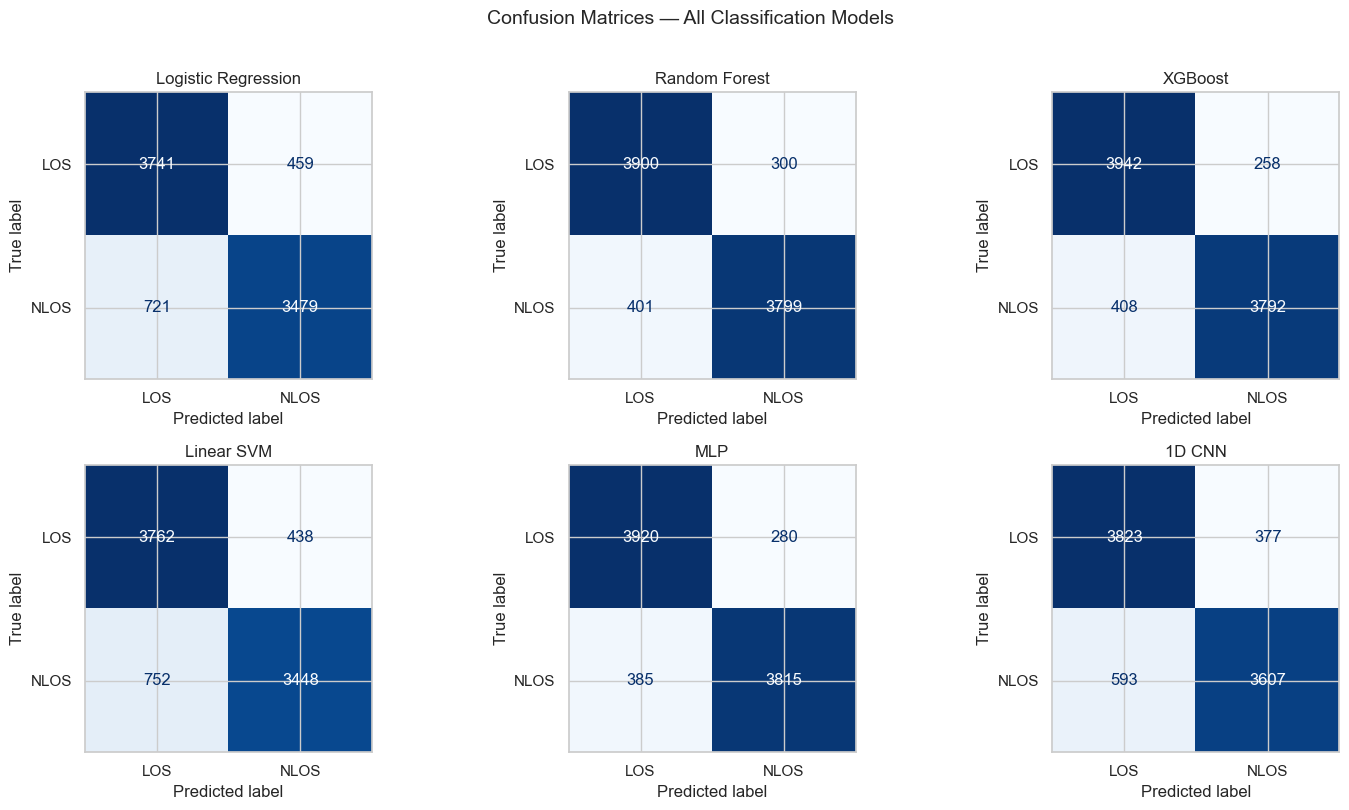

In [15]:
# Confusion matrices ────────────────────────────────────────────────────────
n_models = len(trained_clfs)
n_cols = 3
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()

# Select the appropriate y_test depending on model
cnn_uses_separate_split = TF_AVAILABLE and '1D CNN' in trained_clfs

for idx, (name, (model, y_pred)) in enumerate(trained_clfs.items()):
    # CNN used a separate test split
    if name == '1D CNN' and cnn_uses_separate_split:
        y_true_cm = y_cir_te
    else:
        y_true_cm = y_test

    cm = confusion_matrix(y_true_cm, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['LOS', 'NLOS'])
    disp.plot(ax=axes[idx], colorbar=False, cmap='Blues')
    axes[idx].set_title(name)

for j in range(idx + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Confusion Matrices — All Classification Models', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("results/classification/05_confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()

## Cross-Validation — Generalisation Check

A single 80:20 split tells us how models perform on one particular held-out subset. To confirm the results are stable and not sensitive to which samples ended up in the test set, we run **5-fold stratified cross-validation** on the training data.

Each fold uses a different 20% of the training set as validation while the remaining 80% is used for fitting. The model is trained and evaluated 5 times in total. We report **F1-score** since it balances precision and recall — the most relevant metric for a positioning system where missing an NLOS condition causes localisation error.

A small standard deviation across folds means the model generalises consistently regardless of which data it sees during training.

In [16]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("5-FOLD STRATIFIED CROSS-VALIDATION")
print("=" * 60)
print("Using selected features only. Evaluated on training set — test set remains unseen.\n")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Pipelines handle scaling internally for models that need it
cv_configs = [
    ('Logistic Regression',
     Pipeline([('sc', StandardScaler()),
               ('clf', LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE))])),
    ('Random Forest',
     RandomForestClassifier(n_estimators=200, min_samples_leaf=2,
                            random_state=RANDOM_STATE, n_jobs=-1)),
    ('Linear SVM',
     Pipeline([('sc', StandardScaler()),
               ('clf', LinearSVC(C=1.0, max_iter=5000, random_state=RANDOM_STATE))])),
    ('MLP',
     Pipeline([('sc', StandardScaler()),
               ('clf', MLPClassifier(hidden_layer_sizes=(256, 128, 64),
                                     max_iter=300, random_state=RANDOM_STATE))])),
]
if XGB_AVAILABLE:
    cv_configs.insert(2, (
        'XGBoost',
        xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                           subsample=0.8, colsample_bytree=0.8,
                           eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1)
    ))

cv_summary = {}
print(f"{'Model':<24} {'Mean F1':>9}  {'± Std':>7}   Range")
print("─" * 58)
for name, model in cv_configs:
    scores = cross_val_score(model, X_train_sel, y_train, cv=skf, scoring='f1', n_jobs=-1)
    cv_summary[name] = {'Mean F1': round(scores.mean(), 4), 'Std': round(scores.std(), 4)}
    print(f"{name:<24} {scores.mean():>9.4f}  {scores.std():>7.4f}   "
          f"[{scores.min():.4f} – {scores.max():.4f}]")

print()
cv_df = pd.DataFrame(cv_summary).T
print(cv_df.to_string())
print("\nLow std across folds confirms stable generalisation — test-set results are not a lucky split.")

5-FOLD STRATIFIED CROSS-VALIDATION
Using selected features only. Evaluated on training set — test set remains unseen.

Model                      Mean F1    ± Std   Range
──────────────────────────────────────────────────────────
Logistic Regression         0.8540   0.0034   [0.8500 – 0.8597]
Random Forest               0.9189   0.0029   [0.9142 – 0.9229]
XGBoost                     0.9226   0.0029   [0.9177 – 0.9260]
Linear SVM                  0.8545   0.0022   [0.8514 – 0.8582]
MLP                         0.9117   0.0024   [0.9088 – 0.9157]

                     Mean F1     Std
Logistic Regression   0.8540  0.0034
Random Forest         0.9189  0.0029
XGBoost               0.9226  0.0029
Linear SVM            0.8545  0.0022
MLP                   0.9117  0.0024

Low std across folds confirms stable generalisation — test-set results are not a lucky split.


---
## Final Summary — Task 1

In [17]:
print("=" * 70)
print("TASK 1 — CLASSIFICATION FINAL RESULTS")
print("=" * 70)
print(pd.DataFrame(clf_results).T.round(4).sort_values("AUC-ROC", ascending=False).to_string())

TASK 1 — CLASSIFICATION FINAL RESULTS
                     Accuracy  Precision  Recall      F1  AUC-ROC
MLP                    0.9208     0.9316  0.9083  0.9198   0.9776
XGBoost                0.9207     0.9363  0.9029  0.9193   0.9773
Random Forest          0.9165     0.9268  0.9045  0.9155   0.9739
1D CNN                 0.8845     0.9054  0.8588  0.8815   0.9501
Logistic Regression    0.8595     0.8834  0.8283  0.8550   0.9242
Linear SVM             0.8583     0.8873  0.8210  0.8528   0.9241
